<a href="https://colab.research.google.com/github/satisumit/Soybean-CNN-Analysis/blob/main/notebooks/SBMC_ResNet152V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, callbacks, models
import os, random, numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import shutil
import time
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================================
# STEP 1: SETUP AND DATA LOADING (Using fast local storage copy)
# ============================================================================
print("=" * 70)
print("STEP 1: Setting up environment and fast data loading")
print("=" * 70)

# Mount Google Drive
try:
    drive.mount('/content/drive')
except Exception as e:
    print(f"Drive mount failed: {e}. Ensure you are in a Colab environment.")

# Define paths
gdrive_path = "/content/drive/MyDrive/Datasets/SoybeanImagessplitted/"
local_path = "/root/soybean_data/"
savepath = "/content/drive/MyDrive/Collabs/SoybeanMultiClass_ResNet152V2/"
os.makedirs(savepath, exist_ok=True)

# Copy data to local Colab storage for faster I/O
if not os.path.exists(local_path):
    print("\n📂 Copying dataset from Google Drive to local Colab storage...")
    start_time = time.time()
    try:
        os.system(f'cp -r "{gdrive_path}" "{local_path}"')
        elapsed = time.time() - start_time
        print(f"✓ Copy complete in {elapsed:.1f} seconds!")
    except Exception:
        print(f"🚨 Local copy failed. Falling back to Google Drive path.")
        local_path = gdrive_path
else:
    print(f"✓ Data already copied to {local_path}")

# Use path (local or drive)
datapath = local_path
train_data_dir = datapath + "train"
val_data_dir = datapath + "val"
test_data_dir = datapath + "test"

STEP 1: Setting up environment and fast data loading
Mounted at /content/drive

📂 Copying dataset from Google Drive to local Colab storage...
✓ Copy complete in 469.7 seconds!


In [ ]:

# ============================================================================
# STEP 2: HYPERPARAMETERS & SEEDING
# ============================================================================

SEED = 1234
dim = (224, 224)
epochs_phase1 = 20  # Initial training epochs
epochs_phase2 = 30 # Fine-tuning epochs
batch_size = 16
classes = 4
initial_learning_rate = 0.0005 # Lowered initial LR for better stability

def seed_all(SEED):
    tf.random.set_seed(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    os.environ['PYTHONHASHSEED'] = str(SEED)

seed_all(SEED)

# Enable mixed precision for faster training on GPUs/TPUs
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f"\n✓ Mixed precision policy set to: {policy.name}")



✓ Mixed precision policy set to: mixed_float16


In [ ]:

# ============================================================================
# STEP 3: CREATE TF.DATA PIPELINE
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: Creating optimized tf.data pipeline")
print("=" * 70)

def create_dataset(directory, target_size=dim, batch_size=batch_size, shuffle=True):
    """Creates an optimized tf.data pipeline."""
    dataset = tf.keras.utils.image_dataset_from_directory(
        directory,
        seed=SEED,
        image_size=target_size,
        batch_size=batch_size,
        shuffle=shuffle,
        label_mode='categorical'
    )

    if not hasattr(create_dataset, 'class_names'):
        create_dataset.class_names = dataset.class_names

    # Pre-fetch and cache for performance
    dataset = dataset.cache().prefetch(tf.data.AUTOTUNE)
    return dataset

# Create initial datasets
train_generator = create_dataset(train_data_dir, shuffle=True)
validation_generator = create_dataset(val_data_dir, shuffle=False)
test_generator = create_dataset(test_data_dir, shuffle=False)

print("✓ Datasets created!")
print(f"✓ Classes detected: {create_dataset.class_names}")



STEP 3: Creating optimized tf.data pipeline
Found 2063 files belonging to 4 classes.
Found 255 files belonging to 4 classes.
Found 231 files belonging to 4 classes.
✓ Datasets created!
✓ Classes detected: ['Aerial_Blight', 'Bacterial_Pustule', 'Healthy', 'Yellow_Mosaic_Virus']


In [ ]:
# ============================================================================
# STEP 4: COMPUTE CLASS WEIGHTS (Essential for low accuracy/imbalance)
# ============================================================================

print("\n" + "=" * 70)
print("STEP 4: Computing class weights for imbalance")
print("=" * 70)

# Extract labels for class weight calculation
y_train = []
train_count = 0
for images, labels in train_generator.unbatch():
    y_train.append(np.argmax(labels.numpy()))
    train_count += 1

y_train = np.array(y_train)

# Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

print(f"📊 Training image count: {train_count}")
print(f"✓ Class weights computed: {class_weights}")



STEP 4: Computing class weights for imbalance
📊 Training image count: 2063
✓ Class weights computed: {0: np.float64(1.1385209713024282), 1: np.float64(0.9975822050290135), 2: np.float64(0.8969565217391304), 3: np.float64(0.9956563706563707)}


In [ ]:
# ============================================================================
# STEP 5: AUGMENTATION LAYER DEFINITION & MAPPING FUNCTION
# ============================================================================
data_augmentation_sequence = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.15, 0.15),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name='Augmentation_Layer')

def augment_batch(images, labels):
    """Applies the augmentation layer to a batch of images."""
    return data_augmentation_sequence(images, training=True), labels

print("\n✓ Augmentation sequence and mapping function defined.")

augmented_train_generator = train_generator.map(
    augment_batch, num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)


✓ Augmentation sequence and mapping function defined.


In [ ]:
# ============================================================================
# STEP 6: BUILD OPTIMIZED MODEL (ResNet152V2)
# ============================================================================
print("\n" + "=" * 70)
print("STEP 6: Building Optimized Model (ResNet152V2)")
print("=" * 70)

def build_model():
    base_model = tf.keras.applications.ResNet152V2(
        input_shape=(224, 224, 3), include_top=False, weights="imagenet"
    )
    base_model.trainable = False
    inputs = layers.Input(shape=(224, 224, 3))
    x = tf.keras.applications.resnet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(classes, activation='softmax', dtype='float32', name='predictions')(x)
    return models.Model(inputs, outputs), base_model

model, base_model = build_model()
print("✓ Model built with ResNet152V2!")



STEP 6: Building Optimized Model (ResNet152V2)
234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
✓ Model built with ResNet152V2!


In [ ]:

# ============================================================================
# STEP 7: PHASE 1
# ============================================================================
print("\n🔥 Starting Phase 1 (ResNet152V2)...")
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_learning_rate),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

callbacks_phase1 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(savepath + 'best_r152v2_p1.h5', monitor='val_accuracy', save_best_only=True)
]

history1 = model.fit(augmented_train_generator, validation_data=validation_generator,
                    epochs=epochs_phase1, callbacks=callbacks_phase1, class_weight=class_weights)



🔥 Starting Phase 1 (ResNet152V2)...
Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.6880 - auc: 0.8908 - loss: 8.2546

129/129 ━━━━━━━━━━━━━━━━━━━━ 124s 693ms/step - accuracy: 0.6888 - auc: 0.8913 - loss: 8.2467 - val_accuracy: 0.9294 - val_auc: 0.9925 - val_loss: 5.4833
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.8485 - auc: 0.9647 - loss: 5.2430

129/129 ━━━━━━━━━━━━━━━━━━━━ 50s 385ms/step - accuracy: 0.8486 - auc: 0.9647 - loss: 5.2396 - val_accuracy: 0.9451 - val_auc: 0.9963 - val_loss: 3.8135
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.8832 - auc: 0.9773 - loss: 3.6715

129/129 ━━━━━━━━━━━━━━━━━━━━ 83s 387ms/step - accuracy: 0.8832 - auc: 0.9773 - loss: 3.6693 - val_accuracy: 0.9804 - val_auc: 0.9981 - val_loss: 2.7135
Epoch 4/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 45s 347ms/step - accuracy: 0.8794 - auc: 0.9790 - loss: 2.6686 - val_accuracy: 0.9451 - val_auc: 0.9968 - val_loss: 2.0122
Epoch 5/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 80s 334ms/step - accuracy: 0.8999 - auc: 0.9842 - loss: 1.9749 - val_accuracy: 0.9608 - val_auc: 0.9968 - val_loss: 1.5593
Epoch 6/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 44s 334ms/step - accuracy: 0.9151 - auc: 0.9870 - loss: 1.5356 - val_accuracy: 0.9608 - val_auc: 0.9984 - val_loss: 1.2249
Epoch 7/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 44s 335ms/step - accuracy: 0.8967 - auc: 0.9863 - loss: 1.2711 - val_accuracy: 0.9686 - val_auc: 0.9990 - val_loss: 1.0205
Epoch 8/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 82s 328ms/step - accuracy: 0.9081 - auc: 0.9883 - loss: 1.0838 - val_accuracy: 0.9686 - val_auc: 0.9983 - val_loss: 0.9062


In [ ]:

# ============================================================================
# STEP 8: PHASE 2 (Last 50 Layers)
# ============================================================================
print("\n🔥 Starting Phase 2 (ResNet152V2)...")
model.load_weights(savepath + 'best_r152v2_p1.h5')
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_learning_rate * 0.05),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

callbacks_phase2 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True),
    callbacks.ModelCheckpoint(savepath + 'best_r152v2_final.h5', monitor='val_accuracy', save_best_only=True)
]

history2 = model.fit(augmented_train_generator, validation_data=validation_generator,
                    epochs=epochs_phase2, callbacks=callbacks_phase2, class_weight=class_weights)



🔥 Starting Phase 2 (ResNet152V2)...
Epoch 1/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.8721 - auc: 0.9750 - loss: 2.8612

129/129 ━━━━━━━━━━━━━━━━━━━━ 133s 643ms/step - accuracy: 0.8722 - auc: 0.9751 - loss: 2.8608 - val_accuracy: 0.9451 - val_auc: 0.9957 - val_loss: 2.7165
Epoch 2/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9218 - auc: 0.9892 - loss: 2.7118

129/129 ━━━━━━━━━━━━━━━━━━━━ 55s 425ms/step - accuracy: 0.9218 - auc: 0.9892 - loss: 2.7116 - val_accuracy: 0.9490 - val_auc: 0.9963 - val_loss: 2.6260
Epoch 3/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9306 - auc: 0.9902 - loss: 2.6204

129/129 ━━━━━━━━━━━━━━━━━━━━ 59s 457ms/step - accuracy: 0.9305 - auc: 0.9902 - loss: 2.6202 - val_accuracy: 0.9529 - val_auc: 0.9978 - val_loss: 2.5395
Epoch 4/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.9402 - auc: 0.9937 - loss: 2.5281

129/129 ━━━━━━━━━━━━━━━━━━━━ 82s 457ms/step - accuracy: 0.9402 - auc: 0.9937 - loss: 2.5280 - val_accuracy: 0.9725 - val_auc: 0.9987 - val_loss: 2.4303
Epoch 5/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 67s 338ms/step - accuracy: 0.9392 - auc: 0.9942 - loss: 2.4507 - val_accuracy: 0.9725 - val_auc: 0.9980 - val_loss: 2.3641
Epoch 6/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 44s 341ms/step - accuracy: 0.9472 - auc: 0.9960 - loss: 2.3722 - val_accuracy: 0.9725 - val_auc: 0.9985 - val_loss: 2.2990
Epoch 7/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.9557 - auc: 0.9963 - loss: 2.2959

129/129 ━━━━━━━━━━━━━━━━━━━━ 54s 419ms/step - accuracy: 0.9558 - auc: 0.9963 - loss: 2.2958 - val_accuracy: 0.9765 - val_auc: 0.9989 - val_loss: 2.2239
Epoch 8/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 71s 337ms/step - accuracy: 0.9648 - auc: 0.9972 - loss: 2.2170 - val_accuracy: 0.9765 - val_auc: 0.9982 - val_loss: 2.1441
Epoch 9/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 44s 338ms/step - accuracy: 0.9606 - auc: 0.9979 - loss: 2.1409 - val_accuracy: 0.9765 - val_auc: 0.9996 - val_loss: 2.0653
Epoch 10/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9781 - auc: 0.9983 - loss: 2.0661

129/129 ━━━━━━━━━━━━━━━━━━━━ 52s 405ms/step - accuracy: 0.9781 - auc: 0.9983 - loss: 2.0659 - val_accuracy: 0.9804 - val_auc: 0.9998 - val_loss: 1.9963
Epoch 11/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 73s 338ms/step - accuracy: 0.9723 - auc: 0.9985 - loss: 2.0030 - val_accuracy: 0.9804 - val_auc: 0.9996 - val_loss: 1.9315
Epoch 12/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.9769 - auc: 0.9993 - loss: 1.9292

129/129 ━━━━━━━━━━━━━━━━━━━━ 91s 408ms/step - accuracy: 0.9769 - auc: 0.9993 - loss: 1.9290 - val_accuracy: 0.9882 - val_auc: 0.9998 - val_loss: 1.8647
Epoch 13/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9743 - auc: 0.9982 - loss: 1.8712

129/129 ━━━━━━━━━━━━━━━━━━━━ 61s 474ms/step - accuracy: 0.9743 - auc: 0.9982 - loss: 1.8711 - val_accuracy: 0.9922 - val_auc: 0.9997 - val_loss: 1.8017
Epoch 14/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 65s 340ms/step - accuracy: 0.9736 - auc: 0.9989 - loss: 1.8090 - val_accuracy: 0.9922 - val_auc: 0.9998 - val_loss: 1.7383
Epoch 15/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 44s 339ms/step - accuracy: 0.9785 - auc: 0.9992 - loss: 1.7454 - val_accuracy: 0.9882 - val_auc: 0.9998 - val_loss: 1.6798
Epoch 16/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 44s 338ms/step - accuracy: 0.9815 - auc: 0.9995 - loss: 1.6791 - val_accuracy: 0.9922 - val_auc: 0.9999 - val_loss: 1.6182
Epoch 17/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 82s 337ms/step - accuracy: 0.9847 - auc: 0.9994 - loss: 1.6216 - val_accuracy: 0.9882 - val_auc: 0.9998 - val_loss: 1.5655
Epoch 18/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 44s 337ms/step - accuracy: 0.9831 - auc: 0.9996 - loss: 1.5638 - val_accuracy: 0.9882 - val_auc: 0.9998 - val_loss: 1.5080
Epoch 19/30
129/129 ━━━━━━━━


STEP 9: Comprehensive Evaluation
15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9887 - auc: 0.9997 - loss: 1.8010

🎯 FINAL TEST RESULTS:
    Test Accuracy: 98.70%
    Test Loss: 1.8078
    Test AUC: 0.9997
Generating predictions for confusion matrix...
    Processed 10 batches...

📊 CLASSIFICATION REPORT:
                     precision    recall  f1-score   support

      Aerial_Blight       1.00      0.98      0.99        51
  Bacterial_Pustule       0.98      1.00      0.99        58
            Healthy       0.97      1.00      0.98        64
Yellow_Mosaic_Virus       1.00      0.97      0.98        58

           accuracy                           0.99       231
          macro avg       0.99      0.99      0.99       231
       weighted avg       0.99      0.99      0.99       231



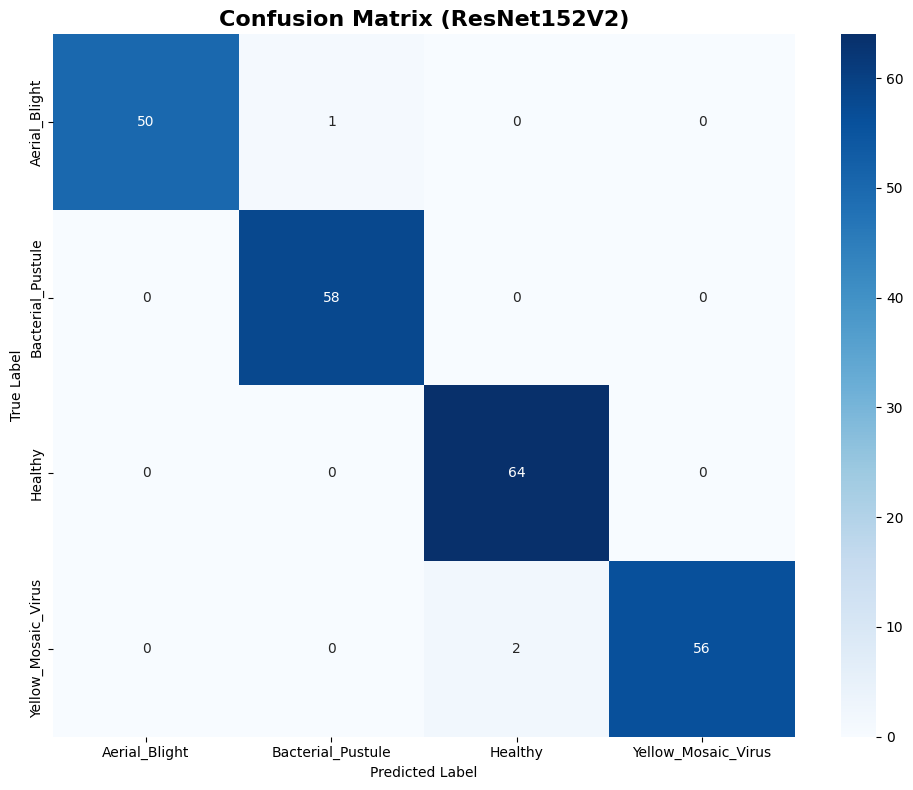


✓ Confusion Matrix saved.


In [ ]:
# ============================================================================
# STEP 9: Comprehensive Evaluation
# ============================================================================
print("\n" + "=" * 70)
print("STEP 9: Comprehensive Evaluation")
print("=" * 70)

test_results = model.evaluate(test_generator, verbose=1)

test_loss = test_results[0]
test_accuracy = test_results[1]
test_auc = test_results[2]

print(f"\n🎯 FINAL TEST RESULTS:")
print(f"    Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"    Test Loss: {test_loss:.4f}")
print(f"    Test AUC: {test_auc:.4f}")

y_pred = []
y_true = []
class_names = create_dataset.class_names
print("Generating predictions for confusion matrix...")

test_iterator = iter(test_generator)
i = 0
while True:
    try:
        images, labels = next(test_iterator)
        preds = model.predict_on_batch(images)

        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        i += 1
        if i % 10 == 0:
            print(f"    Processed {i} batches...")
    except StopIteration:
        break

print("\n📊 CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=class_names,
             yticklabels=class_names)
plt.title('Confusion Matrix (ResNet152V2)', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(savepath + 'confusion_matrix_ResNet152V2.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Confusion Matrix saved.")




STEP 10: Generating visualizations


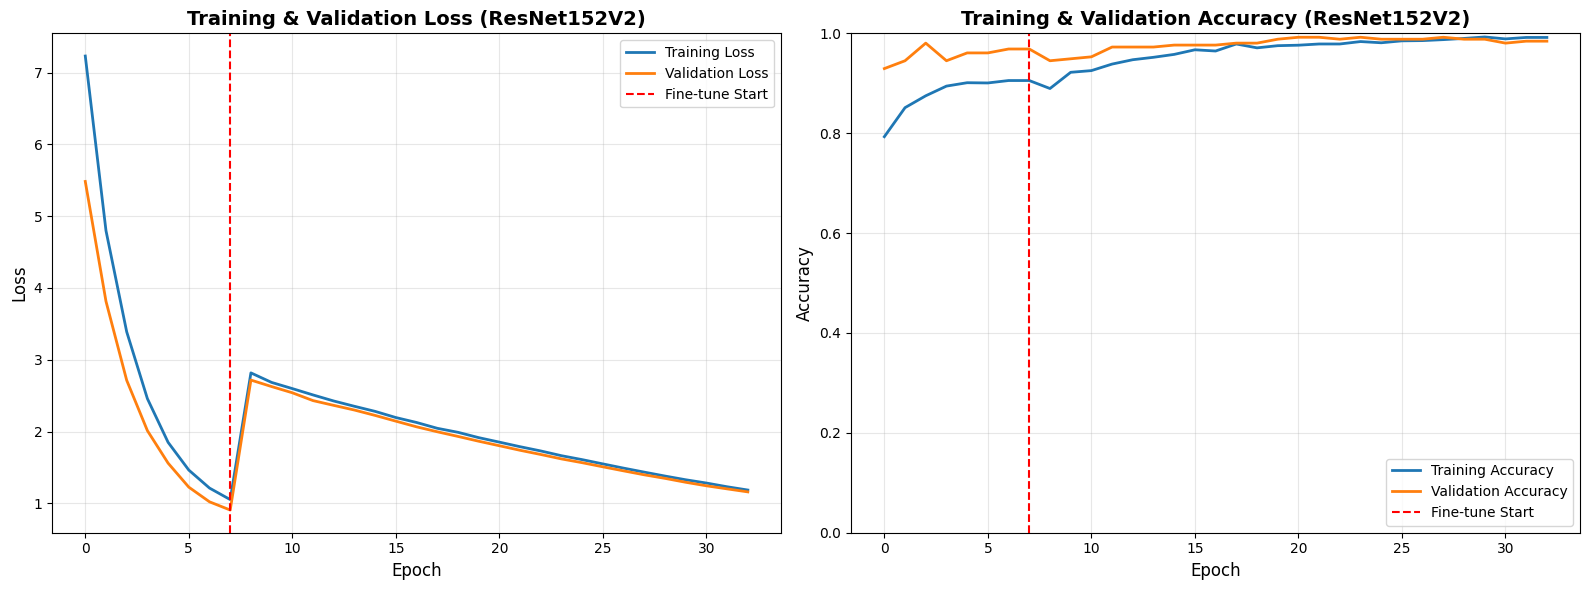


✓ Saved training metrics to: /content/drive/MyDrive/Collabs/SoybeanMultiClass_ResNet152V2/training_metrics_ResNet152V2.csv


In [ ]:
# ============================================================================
# STEP 10: Generating visualizations (PLOTTING HISTORY)
# ============================================================================
print("\n" + "=" * 70)
print("STEP 10: Generating visualizations")
print("=" * 70)

class DummyHistory:
    def __init__(self, history):
        self.history = history

def plot_combined_history(hist1, hist2):
    """Combines and plots the training history for both phases."""

    hist1_dict = hist1.history
    hist2_dict = hist2.history

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    total_loss = hist1_dict['loss'] + hist2_dict['loss']
    total_val_loss = hist1_dict['val_loss'] + hist2_dict['val_loss']
    total_acc = hist1_dict['accuracy'] + hist2_dict['accuracy']
    total_val_acc = hist1_dict['val_accuracy'] + hist2_dict['val_accuracy']

    # Loss plot
    axes[0].plot(total_loss, label='Training Loss', linewidth=2)
    axes[0].plot(total_val_loss, label='Validation Loss', linewidth=2)
    axes[0].axvline(x=len(hist1_dict['loss']) - 1, color='red', linestyle='--', label='Fine-tune Start')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training & Validation Loss (ResNet152V2)', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(total_acc, label='Training Accuracy', linewidth=2)
    axes[1].plot(total_val_acc, label='Validation Accuracy', linewidth=2)
    axes[1].axvline(x=len(hist1_dict['loss']) - 1, color='red', linestyle='--', label='Fine-tune Start')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training & Validation Accuracy (ResNet152V2)', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])

    plt.tight_layout()
    plt.savefig(savepath + 'training_history_ResNet152V2.png', dpi=300, bbox_inches='tight')
    plt.show()

# Execute the plotting function
plot_combined_history(history1, history2)


# Save metrics to CSV
combined_epochs = list(range(1, len(history1.history['loss']) + len(history2.history['loss']) + 1))
df_metrics = pd.DataFrame({
    'epochs': combined_epochs,
    'training_loss': history1.history['loss'] + history2.history['loss'],
    'validation_loss': history1.history['val_loss'] + history2.history['val_loss'],
    'training_accuracy': history1.history['accuracy'] + history2.history['accuracy'],
    'validation_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy']
})
df_metrics.to_csv(savepath + "training_metrics_ResNet152V2.csv", sep=',', index=False)
print(f"\n✓ Saved training metrics to: {savepath}training_metrics_ResNet152V2.csv")